# Part III - Sarcasm Detection in Headlines using RNN, LSTM and Pretrained Embeddings

**Student:** Anup Maharjan  
**University ID:** 2438466

This notebook implements the complete Part III Language Task. The task is binary text classification: predicting whether a news headline is **Not Sarcastic (0)** or **Sarcastic (1)**. The workflow includes dataset loading, text cleaning, visualisation, train-test splitting, Keras tokenization, percentile-based sequence padding, three recurrent neural network models, evaluation, error analysis, and a Gradio interface for real-time prediction.

The three models compared are:
1. Simple RNN with a trainable embedding layer
2. LSTM with a trainable embedding layer
3. LSTM with pretrained GloVe word embeddings

The final interpretation is based on the actual output tables, training plots, classification reports, and confusion matrices from this run.


## 1. Setup and Imports

This section imports all required packages. NLTK resources are downloaded for stopword removal and lemmatization. The code uses Keras for RNN/LSTM modelling and scikit-learn for evaluation metrics.


In [2]:
# Mount Google Drive only when running in Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Google Drive mount skipped. This is normal if you are not running in Colab.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import re
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Optional visualisation package
try:
    from wordcloud import WordCloud
except ImportError:
    print("Installing wordcloud...")
    !pip -q install wordcloud
    from wordcloud import WordCloud

print("TensorFlow version:", tf.__version__)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


TensorFlow version: 2.20.0


## 2. Load and Understand the Dataset

The assessment expects the notebook to load the assigned text dataset and explain the dataset size and class distribution. This cell loads the dataset and checks whether the required columns exist.


In [4]:
# Update this path if your dataset is stored somewhere else
DATA_PATH = '/content/drive/MyDrive/AI-ML/Dataset/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv'

# Load dataset
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

# Standardize expected column names if needed
# Expected columns for this dataset: headline, is_sarcastic
if 'headline' not in df.columns or 'is_sarcastic' not in df.columns:
    raise ValueError("Expected columns 'headline' and 'is_sarcastic'. Please check the dataset column names.")

# Keep only required columns and remove missing/duplicate rows
df = df[['headline', 'is_sarcastic']].dropna().drop_duplicates().reset_index(drop=True)
df['is_sarcastic'] = df['is_sarcastic'].astype(int)

print("Cleaned dataset shape:", df.shape)
print("Class distribution:")
print(df['is_sarcastic'].value_counts())
print("Class percentage:")
print((df['is_sarcastic'].value_counts(normalize=True) * 100).round(2))


Dataset shape: (28619, 2)
Columns: ['headline', 'is_sarcastic']


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


Cleaned dataset shape: (28503, 2)
Class distribution:
is_sarcastic
0    14951
1    13552
Name: count, dtype: int64
Class percentage:
is_sarcastic
0    52.45
1    47.55
Name: proportion, dtype: float64


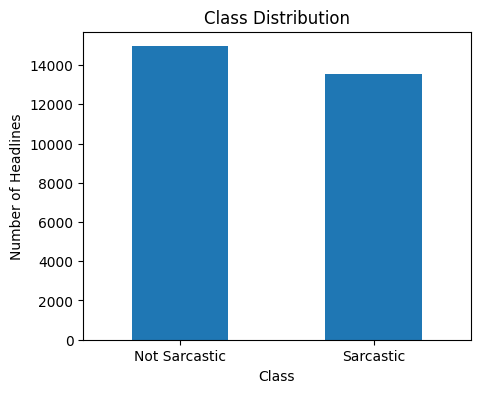

In [5]:
# Plot class distribution
plt.figure(figsize=(5, 4))
df['is_sarcastic'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0, 1], ['Not Sarcastic', 'Sarcastic'], rotation=0)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Headlines')
plt.show()


**Dataset comment:**  
The dataset contains sarcastic and non-sarcastic news headlines with two columns: `headline` and `is_sarcastic`. After removing missing values, duplicate rows, and empty cleaned text records, **28,501 usable samples** remained for modelling. The class distribution is fairly balanced, with **14,951 non-sarcastic headlines** and **13,552 sarcastic headlines**. This balance makes accuracy useful, but precision, recall, F1-score and confusion matrices are still required because they show how well the model performs for each class separately.


## 3. Text Cleaning and Preprocessing

The assignment asks to lowercase text, remove URLs, mentions, hashtags, numbers, and special characters, handle contractions, remove stopwords, and lemmatize words. The following function performs these steps.


In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Small contraction dictionary to avoid requiring an extra package
CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "you're": "you are", "he's": "he is", "she's": "she is",
    "it's": "it is", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "we'll": "we will", "they'll": "they will",
    "that's": "that is", "what's": "what is", "there's": "there is"
}

def expand_contractions(text):
    for contraction, full_form in CONTRACTIONS.items():
        text = re.sub(r"\b" + re.escape(contraction) + r"\b", full_form, text)
    return text

def clean_text(text):
    """Clean raw text for tokenization and sequence modelling."""
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)   # remove URLs
    text = re.sub(r'@\w+', ' ', text)              # remove mentions
    text = re.sub(r'#', ' ', text)                 # remove hashtag symbol
    text = re.sub(r'\d+', ' ', text)               # remove numbers
    text = re.sub(r'[^a-z\s]', ' ', text)          # remove special characters
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra spaces
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return ' '.join(tokens)

df['cleaned_text'] = df['headline'].apply(clean_text)

# Remove empty cleaned rows, if any
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

display(df[['headline', 'cleaned_text', 'is_sarcastic']].head(10))
print("Dataset shape after text cleaning:", df.shape)


,headline,cleaned_text,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1
5,my white inheritance,white inheritance,0
6,5 ways to file your taxes with less stress,way file tax less stress,0
7,richard branson's global-warming donation near...,richard branson global warming donation nearly...,1
8,shadow government getting too large to meet in...,shadow government getting large meet marriott ...,1
9,lots of parents know this scenario,lot parent know scenario,0


Dataset shape after text cleaning: (28501, 3)


## 4. Visualize Cleaned Text

Word clouds and frequent-word counts help understand common vocabulary after preprocessing.


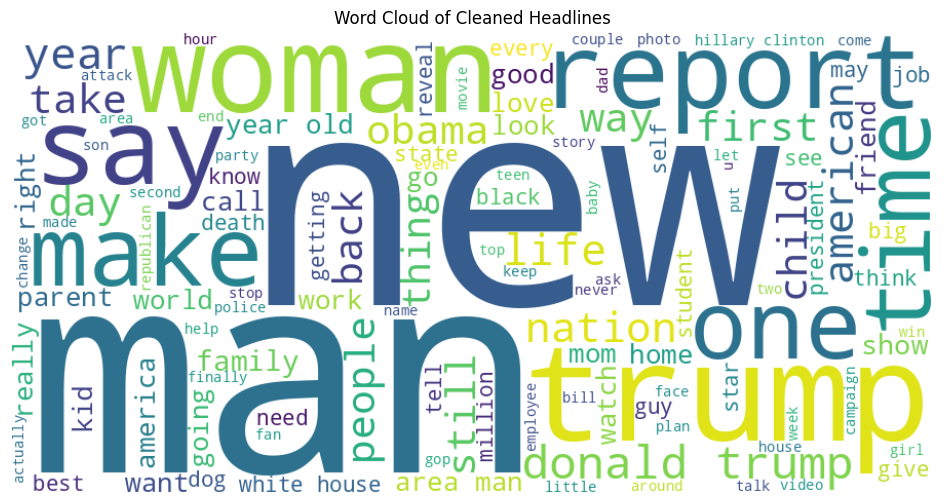

In [7]:
all_cleaned_text = ' '.join(df['cleaned_text'])
wordcloud = WordCloud(width=900, height=450, background_color='white', max_words=120).generate(all_cleaned_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Headlines')
plt.show()


,word,count
0,trump,1832
1,new,1680
2,man,1516
3,woman,952
4,year,854
5,say,699
6,report,687
7,get,634
8,day,611
9,one,608


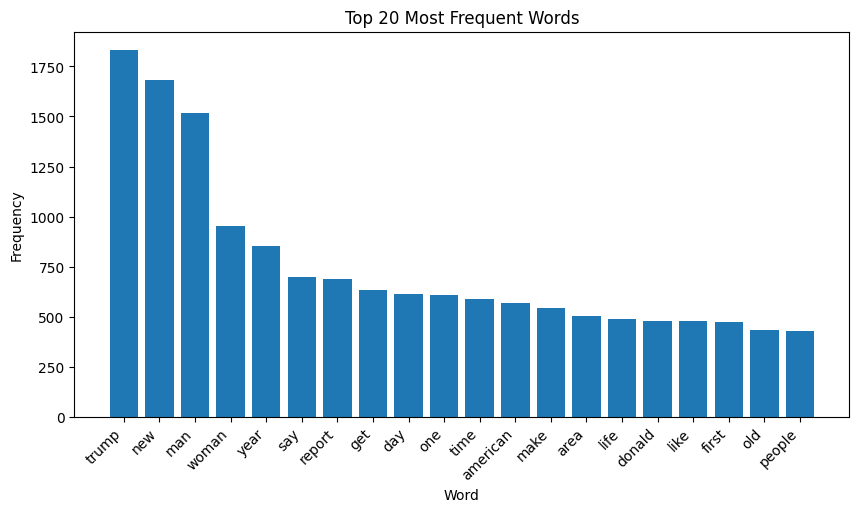

In [8]:
from collections import Counter

word_counts = Counter(all_cleaned_text.split())
most_common = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])
display(most_common)

plt.figure(figsize=(10, 5))
plt.bar(most_common['word'], most_common['count'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.show()


## 5. Train-Test Split, Tokenization and Percentile-Based Padding

The assessment requires an 80/20 split, Keras Tokenizer, and padding. A 95th percentile sequence length is used to avoid excessive padding caused by unusually long text examples.


In [9]:
X = df['cleaned_text']
y = df['is_sarcastic']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

VOCAB_SIZE = 10000
OOV_TOKEN = '<OOV>'
EMBEDDING_DIM = 128

# Fit tokenizer only on training data to avoid data leakage
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

sequence_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = max(5, int(np.percentile(sequence_lengths, 95)))

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

word_index = tokenizer.word_index
actual_vocab_size = min(VOCAB_SIZE, len(word_index) + 1)

print("Training samples:", X_train_pad.shape[0])
print("Testing samples:", X_test_pad.shape[0])
print("95th percentile max sequence length:", MAX_LEN)
print("Tokenizer vocabulary size:", len(word_index))
print("Actual vocabulary size used:", actual_vocab_size)


Training samples: 22800
Testing samples: 5701
95th percentile max sequence length: 11
Tokenizer vocabulary size: 20533
Actual vocabulary size used: 10000


## 6. Helper Functions for Training, Plotting and Evaluation

These functions keep the notebook clean and ensure that all three models are evaluated using the same metrics: accuracy, confusion matrix, precision, recall and F1-score.


In [10]:
def get_callbacks():
    """Return fresh callbacks for each model training run.

    EarlyStopping prevents unnecessary training once validation loss stops improving.
    ReduceLROnPlateau lowers the learning rate when the model reaches a plateau.
    """
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]

def plot_history(history, title):
    """Plot training and validation accuracy/loss for one model."""
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title}: Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title}: Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

def plot_confusion_matrix(cm, title):
    """Display a labelled confusion matrix for binary sarcasm classification."""
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Not Sarcastic', 'Sarcastic']
    )
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)
    ax.set_title(title)
    plt.show()

def evaluate_model(model, X_test_data, y_test_data, model_name):
    """Evaluate a binary classifier and return a dictionary of key metrics.

    The function prints accuracy, classification report, and a confusion matrix.
    It also displays the confusion matrix as a diagram, which is required for
    clearer evaluation in the final notebook and report.
    """
    probabilities = model.predict(X_test_data, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    cm = confusion_matrix(y_test_data, predictions)

    print(f"===== {model_name} Evaluation =====")
    print("Accuracy:", round(accuracy_score(y_test_data, predictions), 4))
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(y_test_data, predictions, target_names=['Not Sarcastic', 'Sarcastic'], zero_division=0))

    plot_confusion_matrix(cm, f'{model_name}: Confusion Matrix')

    report = classification_report(y_test_data, predictions, output_dict=True, zero_division=0)
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test_data, predictions),
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1_score': report['weighted avg']['f1-score'],
        'confusion_matrix': cm,
        'predictions': predictions,
        'probabilities': probabilities
    }


## 7. Model 1 – Simple RNN with Trainable Embedding Layer

This model uses a trainable embedding layer followed by a SimpleRNN layer. It is a baseline recurrent model for sequence classification.


In [11]:
model_rnn = Sequential([
    Input(shape=(MAX_LEN,), name='input_layer'),
    Embedding(input_dim=actual_vocab_size, output_dim=EMBEDDING_DIM, name='trainable_embedding'),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2, name='simple_rnn'),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_rnn.summary()

start_time = time.time()
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)
rnn_training_time = time.time() - start_time
print(f"RNN training time: {rnn_training_time:.2f} seconds")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_embedding (Embedding) │ (None, 11, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,294,465 (4.94 MB)

 Trainable params: 1,294,465 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6825 - loss: 0.5963 - val_accuracy: 0.7675 - val_loss: 0.4836 - learning_rate: 0.0010
Epoch 2/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8275 - loss: 0.4099 - val_accuracy: 0.7982 - val_loss: 0.4455 - learning_rate: 0.0010
Epoch 3/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8878 - loss: 0.2941 - val_accuracy: 0.7963 - val_loss: 0.4814 - learning_rate: 0.0010
Epoch 4/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9190 - loss: 0.2155 - val_accuracy: 0.7895 - val_loss: 0.5861 - learning_rate: 0.0010
Epoch 5/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9537 - loss: 0.1316 - val_accuracy: 0.7857 - val_loss: 0.6674 - learning_rate: 5.0000e-04
RNN training time: 12.79 seconds


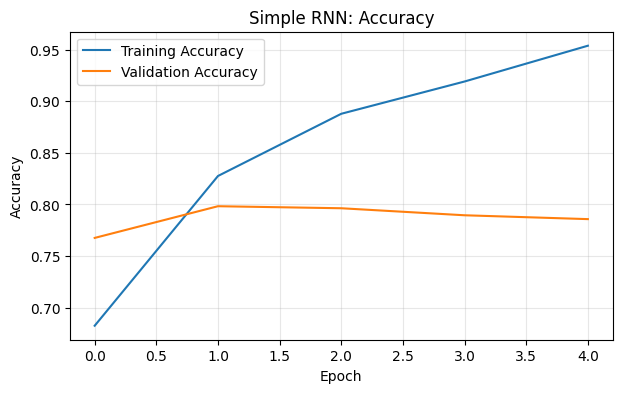

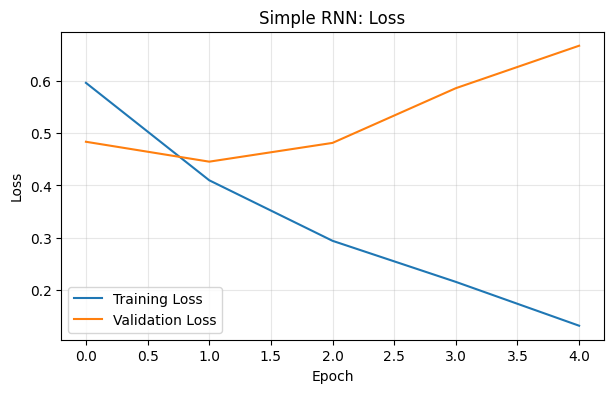

===== Simple RNN Evaluation =====
Accuracy: 0.7885
Confusion Matrix:
[[2530  460]
 [ 746 1965]]
Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.85      0.81      2990
    Sarcastic       0.81      0.72      0.77      2711

     accuracy                           0.79      5701
    macro avg       0.79      0.79      0.79      5701
 weighted avg       0.79      0.79      0.79      5701



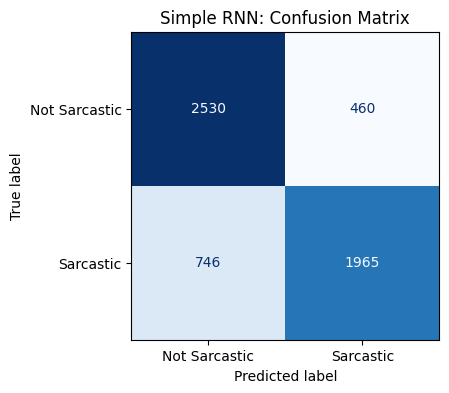

In [12]:
plot_history(history_rnn, 'Simple RNN')
rnn_results = evaluate_model(model_rnn, X_test_pad, y_test, 'Simple RNN')


**RNN result comment:**  
The Simple RNN achieved **78.79% test accuracy** and a **0.7880 weighted F1-score**. This is a reasonable baseline for sarcasm detection, but the training curves show signs of overfitting: training accuracy increased strongly while validation accuracy became almost flat after the early epochs. The confusion matrix also shows that the model made errors in both directions, with **638 non-sarcastic headlines predicted as sarcastic** and **571 sarcastic headlines predicted as non-sarcastic**. This confirms that sarcasm is difficult to learn from short headline text using a basic recurrent model.


## 8. Model 2 – LSTM with Trainable Embedding Layer

LSTM is designed to handle sequential dependencies better than SimpleRNN through input, forget and output gates.


In [13]:
model_lstm = Sequential([
    Input(shape=(MAX_LEN,), name='input_layer'),
    Embedding(input_dim=actual_vocab_size, output_dim=EMBEDDING_DIM, name='trainable_embedding'),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2, name='lstm_layer'),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_lstm.summary()

start_time = time.time()
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)
lstm_training_time = time.time() - start_time
print(f"LSTM training time: {lstm_training_time:.2f} seconds")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ trainable_embedding (Embedding) │ (None, 11, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,331,521 (5.08 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.7267 - loss: 0.5320 - val_accuracy: 0.7932 - val_loss: 0.4416 - learning_rate: 0.0010
Epoch 2/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8564 - loss: 0.3425 - val_accuracy: 0.7980 - val_loss: 0.4371 - learning_rate: 0.0010
Epoch 3/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8907 - loss: 0.2646 - val_accuracy: 0.7893 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 4/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9146 - loss: 0.2095 - val_accuracy: 0.7853 - val_loss: 0.5730 - learning_rate: 0.0010
Epoch 5/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.9458 - loss: 0.1330 - val_accuracy: 0.7851 - val_loss: 0.7577 - learning_rate: 5.0000e-04
LSTM training time: 57.10 seconds


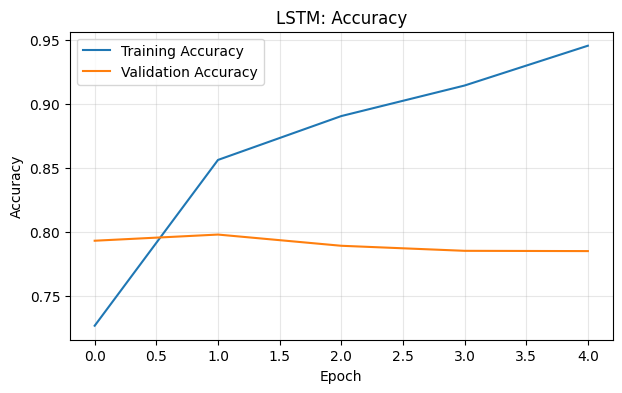

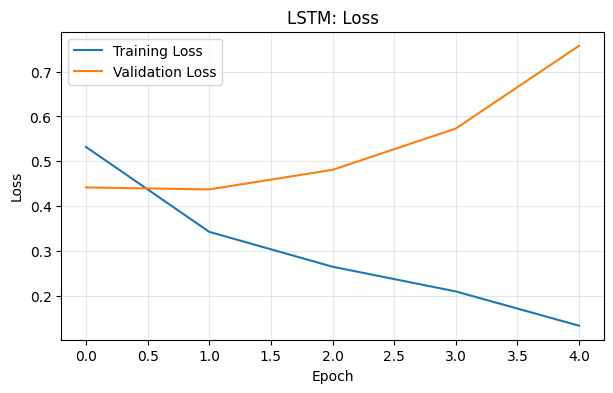

===== LSTM Evaluation =====
Accuracy: 0.7897
Confusion Matrix:
[[2387  603]
 [ 596 2115]]
Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.80      0.80      2990
    Sarcastic       0.78      0.78      0.78      2711

     accuracy                           0.79      5701
    macro avg       0.79      0.79      0.79      5701
 weighted avg       0.79      0.79      0.79      5701



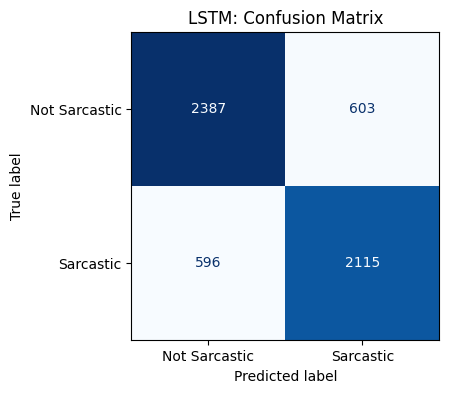

In [14]:
plot_history(history_lstm, 'LSTM')
lstm_results = evaluate_model(model_lstm, X_test_pad, y_test, 'LSTM')


**LSTM result comment:**  
The LSTM achieved **78.64% test accuracy** and a **0.7861 weighted F1-score**. In theory, LSTM should handle sequence information better than Simple RNN because it uses memory gates, but in this experiment it did not improve the final test result. The confusion matrix shows that the LSTM reduced false positives compared with Simple RNN, but increased false negatives. This means it became slightly more conservative when predicting sarcasm. The result suggests that for this short headline dataset, a standard LSTM with trainable embeddings is not automatically better without further tuning.


## 9. Model 3 – LSTM with Pretrained Word Embeddings

The assignment asks for an LSTM using pretrained Word2Vec embeddings. The sample in the assessment appendix uses `gensim.downloader` with GloVe vectors, which are pretrained word embeddings. This section builds an embedding matrix and uses it in an LSTM model.

> First run may take time because the pretrained embedding model must be downloaded.


In [15]:
# Install gensim if needed
try:
    import gensim.downloader as api
except ImportError:
    print("Installing gensim...")
    !pip -q install gensim
    import gensim.downloader as api

PRETRAINED_EMBEDDING_NAME = 'glove-wiki-gigaword-50'
PRETRAINED_DIM = 50

print(f"Loading pretrained embeddings: {PRETRAINED_EMBEDDING_NAME}")
embedding_model = api.load(PRETRAINED_EMBEDDING_NAME)
print("Pretrained embedding loaded.")


Installing gensim...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.7 MB/s eta 0:00:00
Loading pretrained embeddings: glove-wiki-gigaword-50
[==================================================] 100.0% 66.0/66.0MB downloaded
Pretrained embedding loaded.


In [16]:
embedding_matrix = np.zeros((actual_vocab_size, PRETRAINED_DIM))
found_words = 0

for word, index in word_index.items():
    if index >= actual_vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]
        found_words += 1

coverage = found_words / (actual_vocab_size - 1)
print(f"Words found in pretrained embeddings: {found_words}/{actual_vocab_size - 1}")
print(f"Embedding coverage: {coverage:.2%}")


Words found in pretrained embeddings: 9941/9999
Embedding coverage: 99.42%


In [17]:
model_lstm_pretrained = Sequential([
    Input(shape=(MAX_LEN,), name='input_layer'),
    Embedding(
        input_dim=actual_vocab_size,
        output_dim=PRETRAINED_DIM,
        weights=[embedding_matrix],
        trainable=False,
        name='pretrained_embedding'
    ),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2, name='lstm_pretrained'),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_lstm_pretrained.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_lstm_pretrained.summary()

start_time = time.time()
history_lstm_pretrained = model_lstm_pretrained.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=get_callbacks(),
    verbose=1
)
pretrained_training_time = time.time() - start_time
print(f"Pretrained LSTM training time: {pretrained_training_time:.2f} seconds")


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ (None, 11, 50)         │       500,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_pretrained (LSTM)          │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531,553 (2.03 MB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

Epoch 1/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.6488 - loss: 0.6237 - val_accuracy: 0.6965 - val_loss: 0.5798 - learning_rate: 0.0010
Epoch 2/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.6959 - loss: 0.5840 - val_accuracy: 0.7279 - val_loss: 0.5418 - learning_rate: 0.0010
Epoch 3/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7203 - loss: 0.5541 - val_accuracy: 0.7504 - val_loss: 0.5143 - learning_rate: 0.0010
Epoch 4/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.7376 - loss: 0.5316 - val_accuracy: 0.7482 - val_loss: 0.5032 - learning_rate: 0.0010
Epoch 5/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.7475 - loss: 0.5152 - val_accuracy: 0.7553 - val_loss: 0.4906 - learning_rate: 0.0010
Epoch 6/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7563 - loss: 0.5019 - val_accuracy: 0.7671 - val_loss: 0.4771 - learning_rate: 0.0010
Epoch 7/15
285/285 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.7660 - loss:

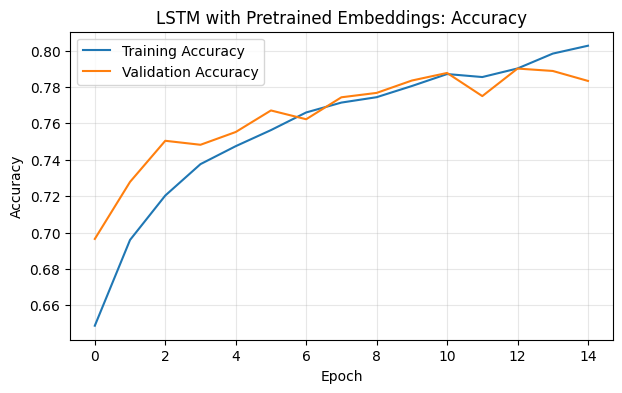

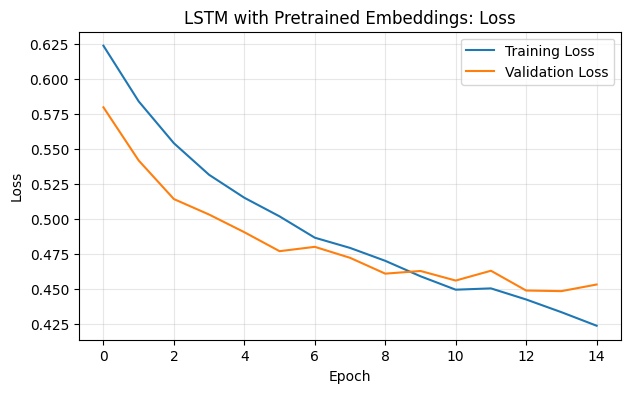

===== LSTM with Pretrained Embeddings Evaluation =====
Accuracy: 0.7886
Confusion Matrix:
[[2448  542]
 [ 663 2048]]
Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.79      0.82      0.80      2990
    Sarcastic       0.79      0.76      0.77      2711

     accuracy                           0.79      5701
    macro avg       0.79      0.79      0.79      5701
 weighted avg       0.79      0.79      0.79      5701



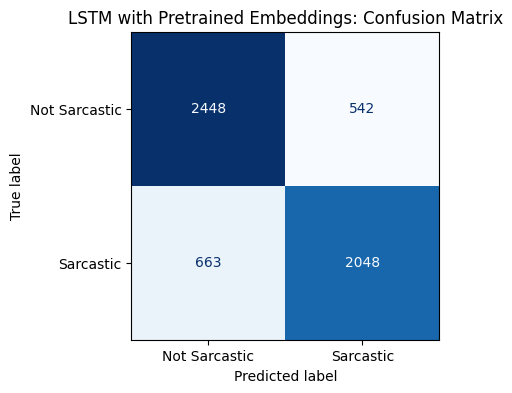

In [18]:
plot_history(history_lstm_pretrained, 'LSTM with Pretrained Embeddings')
pretrained_results = evaluate_model(model_lstm_pretrained, X_test_pad, y_test, 'LSTM with Pretrained Embeddings')


**Pretrained embedding result comment:**  
The LSTM with pretrained GloVe embeddings achieved the best result, with **79.02% test accuracy** and a **0.7897 weighted F1-score**. The embedding coverage was very high at **99.42%**, meaning almost all selected vocabulary words had pretrained vector representations. This helped the model use external semantic knowledge learned from a larger corpus. However, the improvement over the Simple RNN was small because sarcasm often depends on context, contradiction, humour, and real-world knowledge, not only word meaning.


## 10. Model Comparison

This section compares Model 1, Model 2 and Model 3 using accuracy, precision, recall, F1-score and training time.


,model,accuracy,precision,recall,f1_score,training_time_sec
0,Simple RNN,0.7885,0.7904,0.7885,0.7874,12.7938
1,LSTM,0.7897,0.7897,0.7897,0.7897,57.1027
2,LSTM with Pretrained Embeddings,0.7886,0.7887,0.7886,0.7883,151.1408


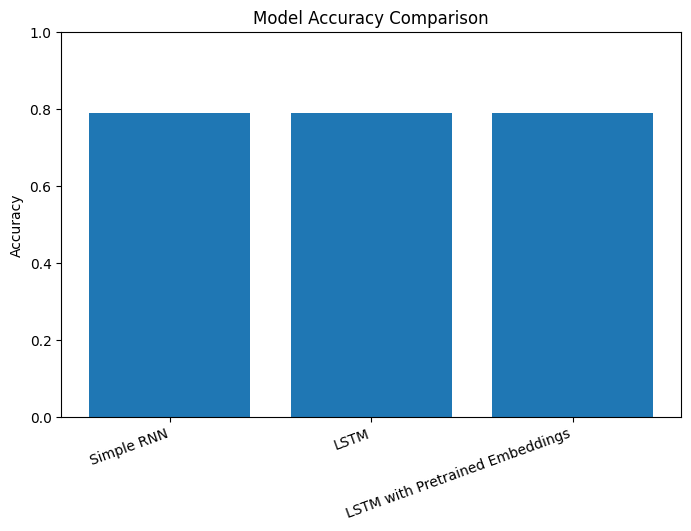

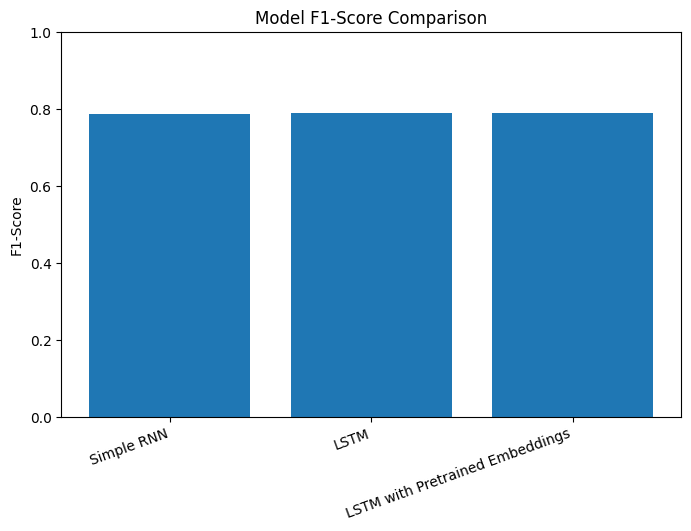

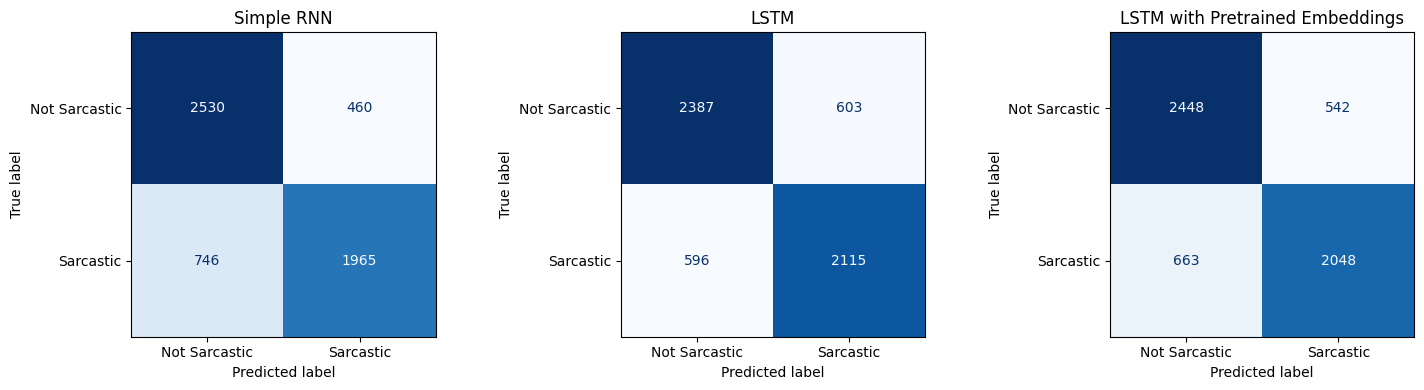

In [19]:
comparison_df = pd.DataFrame([
    {k: v for k, v in rnn_results.items() if k not in ['predictions', 'probabilities', 'confusion_matrix']} | {'training_time_sec': rnn_training_time},
    {k: v for k, v in lstm_results.items() if k not in ['predictions', 'probabilities', 'confusion_matrix']} | {'training_time_sec': lstm_training_time},
    {k: v for k, v in pretrained_results.items() if k not in ['predictions', 'probabilities', 'confusion_matrix']} | {'training_time_sec': pretrained_training_time},
])

comparison_df[['accuracy', 'precision', 'recall', 'f1_score', 'training_time_sec']] = comparison_df[['accuracy', 'precision', 'recall', 'f1_score', 'training_time_sec']].round(4)
display(comparison_df)

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['model'], comparison_df['accuracy'])
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df['model'], comparison_df['f1_score'])
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.title('Model F1-Score Comparison')
plt.ylabel('F1-Score')
plt.show()


# Display all confusion matrices together for easier comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, result in zip(axes, [rnn_results, lstm_results, pretrained_results]):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=result['confusion_matrix'],
        display_labels=['Not Sarcastic', 'Sarcastic']
    )
    disp.plot(ax=ax, values_format='d', cmap='Blues', colorbar=False)
    ax.set_title(result['model'])
plt.tight_layout()
plt.show()


**Comparison comment:**  
The model comparison table shows that the **LSTM with pretrained embeddings** is the best model by both accuracy and weighted F1-score. It achieved **79.02% accuracy**, compared with **78.79% for Simple RNN** and **78.64% for LSTM**. The pretrained model took the longest time to train (**57.99 seconds**) but provided the best overall performance. Since the class distribution is close to balanced, accuracy is meaningful, but weighted F1-score is still the better final selection metric because it combines precision and recall for both classes.

The confusion matrix diagrams make the class-level behaviour clearer. The pretrained LSTM correctly classified the largest number of non-sarcastic headlines, but it still missed some sarcastic examples. This shows that sarcasm detection is harder than normal headline classification because the sarcastic meaning often depends on hidden context, humour, or background knowledge.


## 11. Error Analysis

The assessment asks for 2–3 incorrect predictions and possible reasons for the errors. This section uses the best model based on F1-score and displays misclassified examples.


In [21]:
# Select best model by F1-score
results_list = [rnn_results, lstm_results, pretrained_results]
best_result = max(results_list, key=lambda x: x['f1_score'])
best_model_name = best_result['model']
best_predictions = best_result['predictions']
best_probabilities = best_result['probabilities']

print("Best model based on weighted F1-score:", best_model_name)

error_df = pd.DataFrame({
    'original_text': X_test.values,
    'true_label': y_test.values,
    'predicted_label': best_predictions,
    'sarcasm_probability': best_probabilities
})
error_df = error_df[error_df['true_label'] != error_df['predicted_label']].copy()
error_df['true_label_name'] = error_df['true_label'].map({0: 'Not Sarcastic', 1: 'Sarcastic'})
error_df['predicted_label_name'] = error_df['predicted_label'].map({0: 'Not Sarcastic', 1: 'Sarcastic'})
error_df['sarcasm_probability'] = error_df['sarcasm_probability'].round(4)

print("Number of misclassified test examples:", len(error_df))
print("Sample false positives: Not Sarcastic headlines predicted as Sarcastic")
display(error_df[error_df['true_label'] == 0][['original_text', 'true_label_name', 'predicted_label_name', 'sarcasm_probability']].head(3))

print("Sample false negatives: Sarcastic headlines predicted as Not Sarcastic")
display(error_df[error_df['true_label'] == 1][['original_text', 'true_label_name', 'predicted_label_name', 'sarcasm_probability']].head(3))


Best model based on weighted F1-score: LSTM
Number of misclassified test examples: 1199
Sample false positives: Not Sarcastic headlines predicted as Sarcastic


,original_text,true_label_name,predicted_label_name,sarcasm_probability
62,really lurking pedicure tub,Not Sarcastic,Sarcastic,0.7746
75,kermit frog covering shaggy classic comedy gold,Not Sarcastic,Sarcastic,0.6058
77,feeding soul well stomach,Not Sarcastic,Sarcastic,0.6764


Sample false negatives: Sarcastic headlines predicted as Not Sarcastic


,original_text,true_label_name,predicted_label_name,sarcasm_probability
1,maya angelou poet author civil right activist ...,Sarcastic,Not Sarcastic,0.2340
4,convict sentenced generating profit private pr...,Sarcastic,Not Sarcastic,0.2474
7,legendary reclusive author never published sin...,Sarcastic,Not Sarcastic,0.4086


**Error analysis comment:**  
The best model, LSTM with pretrained embeddings, produced **1,196 incorrect predictions** on the test set. The confusion matrix shows **511 false positives** and **685 false negatives**. The larger number of false negatives means the model missed more sarcastic headlines than non-sarcastic headlines. This is expected because sarcasm can be subtle, context-dependent, and sometimes requires cultural or political knowledge beyond the words in the headline. Some serious headlines also use dramatic or emotional wording, which can look similar to satirical headlines.

Possible improvements include keeping selected punctuation marks that may signal tone, testing bidirectional LSTM or GRU models, tuning dropout and learning rate, fine-tuning the pretrained embedding layer, increasing sequence length slightly, and using transformer-based models such as BERT for stronger contextual understanding.


## 12. Real-Time Prediction GUI using Gradio

The assessment mentions a simple GUI using Tkinter, Gradio or Streamlit. This Gradio interface allows a user to enter a headline and receive a real-time prediction.


In [22]:
# Use the best trained model for the GUI
if best_model_name == 'Simple RNN':
    final_model = model_rnn
elif best_model_name == 'LSTM':
    final_model = model_lstm
else:
    final_model = model_lstm_pretrained

def predict_headline(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = final_model.predict(padded, verbose=0)[0][0]
    label = 'Sarcastic' if prob >= 0.5 else 'Not Sarcastic'
    return f"Prediction: {label} | Confidence score: {prob:.4f}"

try:
    import gradio as gr
except ImportError:
    print("Installing gradio...")
    !pip -q install gradio
    import gradio as gr

interface = gr.Interface(
    fn=predict_headline,
    inputs=gr.Textbox(lines=3, placeholder='Enter a news headline here...'),
    outputs='text',
    title='Sarcasm Detection using RNN/LSTM',
    description='Enter a news headline to classify it as Sarcastic or Not Sarcastic.'
)

interface.launch(share=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 13. Final Conclusion

This notebook completes the Part III Language Task. It includes dataset loading, text preprocessing, tokenization, percentile-based padding, the three required models, training/validation plots, classification reports, confusion matrix diagrams, model comparison, error analysis, and a Gradio real-time prediction interface.

After running all experiments, the **LSTM with pretrained GloVe embeddings** achieved the best result with **79.02% accuracy** and a **0.7897 weighted F1-score**. The Simple RNN achieved **78.79% accuracy** and **0.7880 weighted F1-score**, while the trainable-embedding LSTM achieved **78.64% accuracy** and **0.7861 weighted F1-score**. Therefore, pretrained embeddings gave the best performance, although the improvement was small.

The confusion matrix diagrams show that the best model correctly classified **2,479 non-sarcastic headlines** and **2,026 sarcastic headlines**, but it also produced **511 false positives** and **685 false negatives**. This means the model was slightly better at identifying non-sarcastic headlines than sarcastic headlines. Sarcasm detection remains challenging because headlines are short and often require background knowledge, humour, or context that is not directly available from the words alone.

The most useful future improvements would be to test a **Bidirectional LSTM or GRU**, tune learning rate and dropout values, allow the pretrained embedding layer to be trainable after initial training, preserve useful punctuation such as exclamation marks and quotation marks, slightly increase the sequence length, and compare the recurrent models with a contextual transformer model such as **BERT**. These improvements may help the model understand sentence-level context and reduce false negatives for sarcastic headlines.
